# Rezonans stochastyczny w potencjale bistabilnym

Ten notebook wizualizuje zjawisko rezonansu stochastycznego z wykładu 10: cząstkę lub układ dwustanowy w potencjale bistabilnym, którego bariera jest okresowo modulowana słabym sygnałem. Szum o natężeniu `D` ułatwia przejścia między studniami. Dla odpowiedniego poziomu szumu przejścia synchronizują się z sygnałem okresowym, co daje wyraźny pik w widmie mocy.

Zakres projektu:

- pokazanie okresowej zmiany wysokości bariery potencjału,
- wykresy czasowe prawdopodobieństwa `n_+(t)` oraz losowego sygnału wyjściowego `y(t)`,
- widmo mocy z pikiem przy częstości wymuszenia,
- bez liczenia stosunku sygnału do szumu (SNR).

Model bazuje na przybliżeniu dwustanowym i równaniu Master omawianym na wykładzie. Szybkości przejść są opisane wzorem Kramersa.

In [ ]:
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.figsize": (11, 6),
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
})

FIG_DIR = Path("figury")
FIG_DIR.mkdir(exist_ok=True)


@dataclass(frozen=True)
class Params:
    """Parametry bezwymiarowego modelu rezonansu stochastycznego."""

    barrier0: float = 1.0          # U0: wysokość bariery bez modulacji
    eta0: float = 0.35             # amplituda modulacji bariery, jako część U0
    D: float = 0.28                # natężenie szumu
    omega: float = 0.15            # częstość kątowa sygnału okresowego
    prefactor: float = 1.0         # prefaktor Kramersa
    periods: int = 140             # liczba okresów do symulacji
    transient_periods: int = 20    # okresy odrzucane przed analizą widma
    steps_per_period: int = 320    # rozdzielczość czasowa
    seed: int = 2026

    @property
    def amplitude(self) -> float:
        return self.eta0 * self.barrier0

    @property
    def period(self) -> float:
        return 2 * np.pi / self.omega

    @property
    def dt(self) -> float:
        return self.period / self.steps_per_period


params = Params()


def drive(t, p=params):
    """Słaby sygnał okresowy modulujący wysokości barier."""
    return np.cos(p.omega * np.asarray(t))


def V_s(x, t, p=params):
    """Potencjał bistabilny z okresowym przechyleniem.

    Część (x^2 - 1)^2 daje dwie studnie w pobliżu x = -1 i x = +1.
    Człon liniowy -A x cos(omega t) okresowo obniża raz jedną, raz drugą barierę.
    """
    x = np.asarray(x)
    return p.barrier0 * (x**2 - 1)**2 - p.amplitude * x * drive(t, p)


def barrier_heights(t, p=params):
    """Bariery przejść: lewa -> prawa oraz prawa -> lewa.

    U_siodla = V(0,t) = U0. Dla minimów około x=-1 i x=+1 otrzymujemy
    okresowo zmienne bariery U0 ∓ A cos(omega t).
    """
    modulation = p.amplitude * drive(t, p)
    left_to_right = p.barrier0 - modulation
    right_to_left = p.barrier0 + modulation
    return left_to_right, right_to_left


def transition_rates(t, p=params):
    """Szybkości Kramersa dla przejść między studniami."""
    delta_lr, delta_rl = barrier_heights(t, p)
    w_lr = p.prefactor * np.exp(-delta_lr / p.D)  # -1 -> +1
    w_rl = p.prefactor * np.exp(-delta_rl / p.D)  # +1 -> -1
    return w_lr, w_rl


def time_grid(p=params):
    n = p.periods * p.steps_per_period + 1
    return np.linspace(0, p.periods * p.period, n)

## Potencjał i okresowa zmiana bariery

Poniżej widać ten sam potencjał w czterech fazach wymuszenia. Gdy sygnał okresowy przechyla potencjał, jedna bariera maleje, a druga rośnie. To właśnie okresowe obniżanie barier umożliwia synchronizację przejść wywołanych szumem.

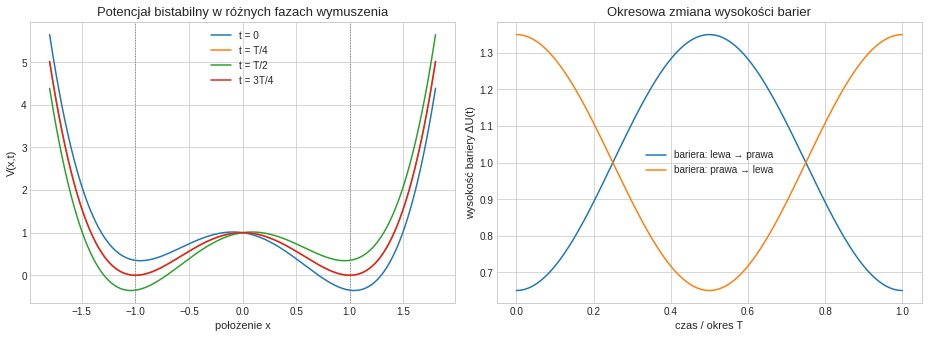

In [ ]:
x = np.linspace(-1.8, 1.8, 500)
phase_times = np.array([0, 0.25, 0.5, 0.75]) * params.period
phase_labels = ["0", "T/4", "T/2", "3T/4"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

for t_phase, label in zip(phase_times, phase_labels):
    axes[0].plot(x, V_s(x, t_phase), label=f"t = {label}")
axes[0].axvline(-1, color="0.5", lw=1, ls=":")
axes[0].axvline(1, color="0.5", lw=1, ls=":")
axes[0].set_title("Potencjał bistabilny w różnych fazach wymuszenia")
axes[0].set_xlabel("położenie x")
axes[0].set_ylabel("V(x,t)")
axes[0].legend()

one_period = np.linspace(0, params.period, 800)
delta_lr, delta_rl = barrier_heights(one_period)
axes[1].plot(one_period / params.period, delta_lr, label="bariera: lewa → prawa")
axes[1].plot(one_period / params.period, delta_rl, label="bariera: prawa → lewa")
axes[1].set_title("Okresowa zmiana wysokości barier")
axes[1].set_xlabel("czas / okres T")
axes[1].set_ylabel("wysokość bariery ΔU(t)")
axes[1].legend()

fig.tight_layout()
fig.savefig(FIG_DIR / "01_potencjal_i_bariery.png", dpi=160)
plt.show()

## Równanie Master i losowy sygnał wyjściowy

W przybliżeniu dwustanowym opisujemy tylko to, czy układ jest w lewej (`-1`) czy prawej (`+1`) studni. Szybkości przejść są zadane wzorem Kramersa: im mniejsza chwilowa bariera i im większy szum `D`, tym większe prawdopodobieństwo przejścia.

Dla prawdopodobieństwa bycia w prawej studni rozwiązujemy równanie Master:

\[
\dot n_+(t)=W_{-\to +}(t)(1-n_+(t))-W_{+\to -}(t)n_+(t).
\]

Oprócz średniej odpowiedzi `n_+(t)` generujemy też losową trajektorię `y(t)=±1`, żeby widmo zawierało zarówno pik okresowy, jak i tło szumowe.

/tmp/ipykernel_18759/2487409226.py:70: UserWarning: Glyph 8330 (\N{SUBSCRIPT PLUS SIGN}) missing from font(s) Liberation Sans.
  fig.tight_layout()
/tmp/ipykernel_18759/2487409226.py:71: UserWarning: Glyph 8330 (\N{SUBSCRIPT PLUS SIGN}) missing from font(s) Liberation Sans.
  fig.savefig(FIG_DIR / "02_master_i_realizacja.png", dpi=160)


/usr/lib/python3/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8330 (\N{SUBSCRIPT PLUS SIGN}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


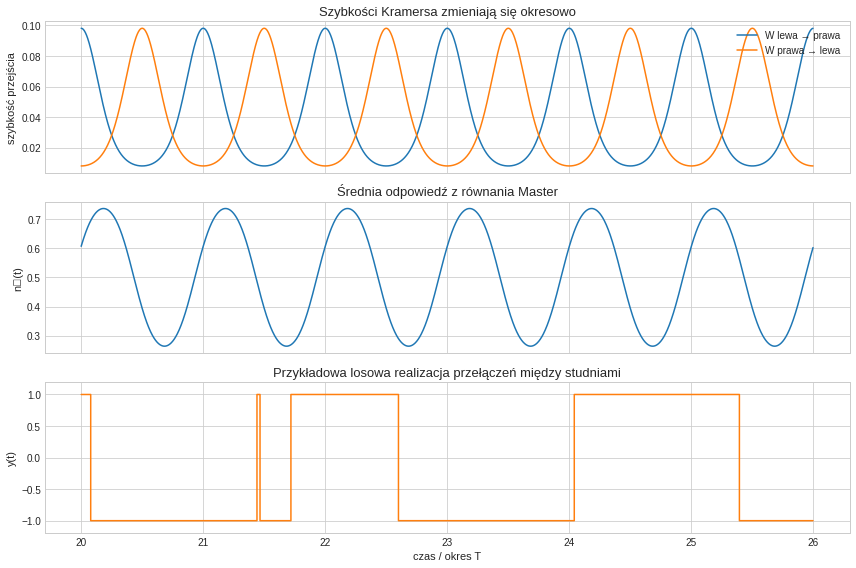

In [ ]:
def solve_master_equation(p=params):
    t_eval = time_grid(p)

    def rhs(t, n):
        w_lr, w_rl = transition_rates(t, p)
        n_plus = n[0]
        return [w_lr * (1 - n_plus) - w_rl * n_plus]

    solution = solve_ivp(
        rhs,
        (t_eval[0], t_eval[-1]),
        y0=[0.5],
        t_eval=t_eval,
        method="DOP853",
        rtol=1e-8,
        atol=1e-10,
    )
    if not solution.success:
        raise RuntimeError(solution.message)
    return solution.t, solution.y[0]


def simulate_two_state_process(p=params, n_realizations=1):
    """Symulacja dyskretna procesu przełączeń z czasowo zależnymi stopami Kramersa."""
    rng = np.random.default_rng(p.seed)
    t = time_grid(p)
    y = np.empty((n_realizations, len(t)), dtype=float)

    for r in range(n_realizations):
        state = rng.choice([-1.0, 1.0])
        y[r, 0] = state
        for i in range(1, len(t)):
            w_lr, w_rl = transition_rates(t[i - 1], p)
            rate = w_lr if state < 0 else w_rl
            switch_probability = 1 - np.exp(-rate * p.dt)
            if rng.random() < switch_probability:
                state *= -1
            y[r, i] = state

    return t, y[0] if n_realizations == 1 else y


t, n_plus = solve_master_equation(params)
y_mean = 2 * n_plus - 1
t, y_sample = simulate_two_state_process(params, n_realizations=1)

w_lr, w_rl = transition_rates(t, params)

plot_start = params.transient_periods * params.steps_per_period
plot_stop = plot_start + 6 * params.steps_per_period
sl = slice(plot_start, plot_stop)

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
axes[0].plot(t[sl] / params.period, w_lr[sl], label="W lewa → prawa")
axes[0].plot(t[sl] / params.period, w_rl[sl], label="W prawa → lewa")
axes[0].set_ylabel("szybkość przejścia")
axes[0].set_title("Szybkości Kramersa zmieniają się okresowo")
axes[0].legend(loc="upper right")

axes[1].plot(t[sl] / params.period, n_plus[sl], color="tab:blue")
axes[1].set_ylabel("n₊(t)")
axes[1].set_title("Średnia odpowiedź z równania Master")

axes[2].step(t[sl] / params.period, y_sample[sl], where="post", color="tab:orange")
axes[2].set_ylabel("y(t)")
axes[2].set_xlabel("czas / okres T")
axes[2].set_title("Przykładowa losowa realizacja przełączeń między studniami")
axes[2].set_ylim(-1.2, 1.2)

fig.tight_layout()
fig.savefig(FIG_DIR / "02_master_i_realizacja.png", dpi=160)
plt.show()

## Autokorelacja i widmo mocy

Z twierdzenia Wienera-Chinczyna widmo mocy jest transformatą Fouriera funkcji autokorelacji. Numerycznie korzystamy z równoważnej postaci periodogramu: po odrzuceniu pierwszych okresów (`transient`) liczymy FFT sygnału `y(t)`. Aby tło szumowe było stabilne, widmo uśredniamy po wielu losowych realizacjach procesu przełączeń.

Na wykresie pionowa linia oznacza częstość wymuszenia `ω`. Oczekiwany efekt to pik widma właśnie w tym miejscu.

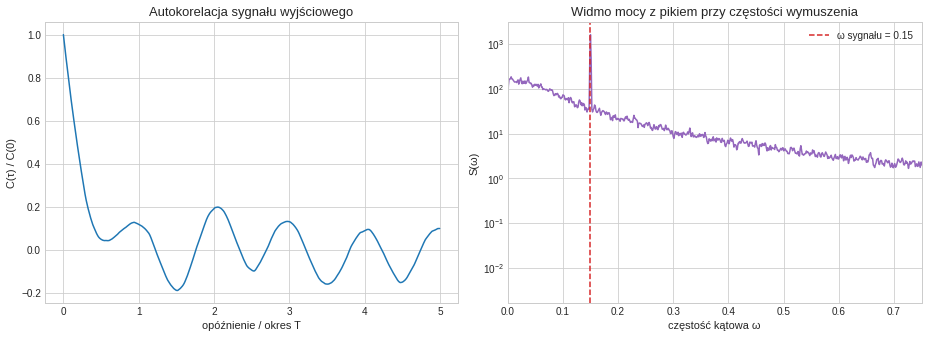

In [ ]:
def autocorrelation_fft(signal):
    """Autokorelacja liczona przez FFT, dla nieujemnych opóźnień."""
    x = np.asarray(signal, dtype=float)
    x = x - x.mean()
    n = len(x)
    fft_values = np.fft.rfft(x, n=2 * n)
    corr = np.fft.irfft(fft_values * np.conj(fft_values), n=2 * n)[:n]
    corr /= np.arange(n, 0, -1)
    return corr / corr[0]


def power_spectrum(signal, dt):
    """Widmo mocy w funkcji częstości kątowej omega."""
    x = np.asarray(signal, dtype=float)
    x = x - x.mean()
    window = np.hanning(len(x))
    xw = x * window
    spectrum = np.abs(np.fft.rfft(xw)) ** 2 / np.sum(window**2)
    omega = 2 * np.pi * np.fft.rfftfreq(len(x), d=dt)
    return omega, spectrum


def averaged_spectrum(p=params, n_realizations=80):
    t, samples = simulate_two_state_process(p, n_realizations=n_realizations)
    samples = samples[:, p.transient_periods * p.steps_per_period :]
    spectra = []
    for sample in samples:
        omega, spectrum = power_spectrum(sample, p.dt)
        spectra.append(spectrum)
    return omega, np.mean(spectra, axis=0), samples[0]


omega_axis, spectrum_avg, y_for_corr = averaged_spectrum(params, n_realizations=80)
correlation = autocorrelation_fft(y_for_corr)
correlation_time = np.arange(len(correlation)) * params.dt

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

corr_limit = 5 * params.steps_per_period
axes[0].plot(correlation_time[:corr_limit] / params.period, correlation[:corr_limit])
axes[0].set_title("Autokorelacja sygnału wyjściowego")
axes[0].set_xlabel("opóźnienie / okres T")
axes[0].set_ylabel("C(τ) / C(0)")

axes[1].semilogy(omega_axis, spectrum_avg, color="tab:purple")
axes[1].axvline(params.omega, color="tab:red", ls="--", label=f"ω sygnału = {params.omega:.2f}")
axes[1].set_xlim(0, 5 * params.omega)
axes[1].set_title("Widmo mocy z pikiem przy częstości wymuszenia")
axes[1].set_xlabel("częstość kątowa ω")
axes[1].set_ylabel("S(ω)")
axes[1].legend()

fig.tight_layout()
fig.savefig(FIG_DIR / "03_autokorelacja_i_widmo.png", dpi=160)
plt.show()

## Figura zbiorcza i wpływ natężenia szumu

Ta część zbiera najważniejsze elementy w jednym układzie: potencjał, bariery, odpowiedź czasową oraz widmo. Dodatkowo porównujemy kilka wartości `D`. Przy zbyt małym szumie przejścia są rzadkie, przy zbyt dużym szumie tracą synchronizację, a dla wartości pośredniej pik przy częstości wymuszenia jest najbardziej widoczny.

/tmp/ipykernel_18759/3454735741.py:41: UserWarning: Glyph 8330 (\N{SUBSCRIPT PLUS SIGN}) missing from font(s) Liberation Sans.
  fig.tight_layout()


/tmp/ipykernel_18759/3454735741.py:42: UserWarning: Glyph 8330 (\N{SUBSCRIPT PLUS SIGN}) missing from font(s) Liberation Sans.
  fig.savefig(FIG_DIR / "04_figura_zbiorcza.png", dpi=180, bbox_inches="tight")


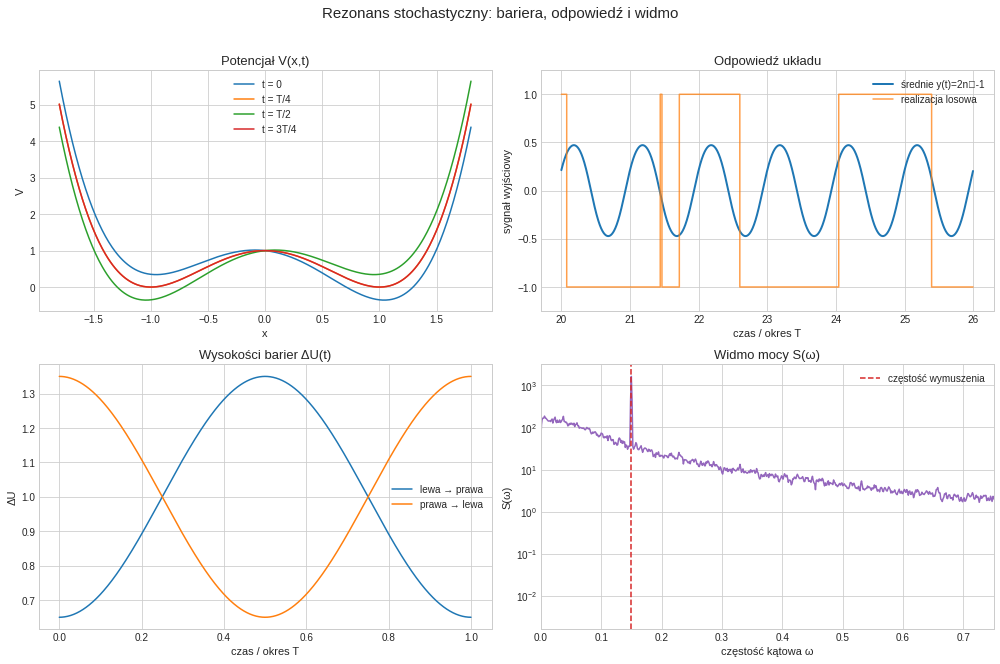

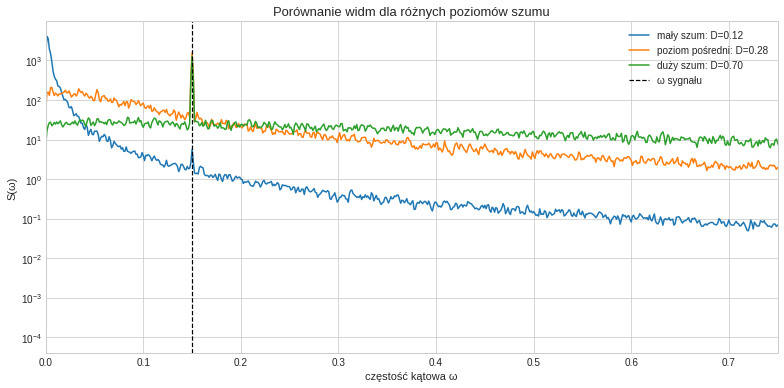

In [ ]:
from dataclasses import replace

fig = plt.figure(figsize=(14, 9))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1.1])
ax_potential = fig.add_subplot(gs[0, 0])
ax_time = fig.add_subplot(gs[0, 1])
ax_barrier = fig.add_subplot(gs[1, 0])
ax_spectrum = fig.add_subplot(gs[1, 1])

for t_phase, label in zip(phase_times, phase_labels):
    ax_potential.plot(x, V_s(x, t_phase), label=f"t = {label}")
ax_potential.set_title("Potencjał V(x,t)")
ax_potential.set_xlabel("x")
ax_potential.set_ylabel("V")
ax_potential.legend()

ax_time.plot(t[sl] / params.period, y_mean[sl], label="średnie y(t)=2n₊-1", lw=2)
ax_time.step(t[sl] / params.period, y_sample[sl], where="post", label="realizacja losowa", alpha=0.75)
ax_time.set_title("Odpowiedź układu")
ax_time.set_xlabel("czas / okres T")
ax_time.set_ylabel("sygnał wyjściowy")
ax_time.set_ylim(-1.25, 1.25)
ax_time.legend(loc="upper right")

ax_barrier.plot(one_period / params.period, delta_lr, label="lewa → prawa")
ax_barrier.plot(one_period / params.period, delta_rl, label="prawa → lewa")
ax_barrier.set_title("Wysokości barier ΔU(t)")
ax_barrier.set_xlabel("czas / okres T")
ax_barrier.set_ylabel("ΔU")
ax_barrier.legend()

ax_spectrum.semilogy(omega_axis, spectrum_avg, color="tab:purple")
ax_spectrum.axvline(params.omega, color="tab:red", ls="--", label="częstość wymuszenia")
ax_spectrum.set_xlim(0, 5 * params.omega)
ax_spectrum.set_title("Widmo mocy S(ω)")
ax_spectrum.set_xlabel("częstość kątowa ω")
ax_spectrum.set_ylabel("S(ω)")
ax_spectrum.legend()

fig.suptitle("Rezonans stochastyczny: bariera, odpowiedź i widmo", y=1.02, fontsize=15)
fig.tight_layout()
fig.savefig(FIG_DIR / "04_figura_zbiorcza.png", dpi=180, bbox_inches="tight")
plt.show()


noise_levels = [0.12, params.D, 0.70]
noise_labels = ["mały szum", "poziom pośredni", "duży szum"]

fig, ax = plt.subplots(figsize=(11, 5.5))
for D_value, label in zip(noise_levels, noise_labels):
    p_variant = replace(params, D=D_value, seed=2026 + int(1000 * D_value))
    omega_variant, spectrum_variant, _ = averaged_spectrum(p_variant, n_realizations=45)
    ax.semilogy(omega_variant, spectrum_variant, label=f"{label}: D={D_value:.2f}")

ax.axvline(params.omega, color="black", ls="--", lw=1.2, label="ω sygnału")
ax.set_xlim(0, 5 * params.omega)
ax.set_title("Porównanie widm dla różnych poziomów szumu")
ax.set_xlabel("częstość kątowa ω")
ax.set_ylabel("S(ω)")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "05_wplyw_poziomu_szumu.png", dpi=160)
plt.show()

## Podsumowanie

Okresowe wymuszenie zmienia wysokości barier potencjału w przeciwnych fazach: gdy jedna bariera maleje, druga rośnie. Szum stochastyczny umożliwia przejścia między studniami, a dla pośredniego natężenia `D` przejścia zaczynają pojawiać się w rytmie sygnału okresowego. W odpowiedzi czasowej widać synchronizację z okresem wymuszenia, a w widmie mocy pojawia się wyraźny pik przy częstości `ω`.

Dla bardzo małego szumu układ zbyt długo pozostaje w jednej studni, więc odpowiedź na sygnał jest słaba. Dla bardzo dużego szumu przejścia są częste, ale mniej zsynchronizowane z wymuszeniem. Najbardziej czytelny rezonans stochastyczny występuje dla wartości pośredniej, gdzie szum pomaga układowi przekraczać barierę wtedy, gdy okresowa modulacja ją obniża.

W projekcie celowo nie liczono SNR, ponieważ wymagane były wizualizacja barier, wykresy czasowe i widmo mocy z pikami.